Train_test_split

In [1]:
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np


In [2]:
data = {
    "Study_Hours" : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Marks"       : [32, 38, 43, 50, 54, 61, 68, 73, 81, 88]
}

In [3]:
df = pd.DataFrame(data)
df

,Study_Hours,Marks
0,1,32
1,2,38
2,3,43
3,4,50
4,5,54
5,6,61
6,7,68
7,8,73
8,9,81
9,10,88


In [4]:
x = df[["Study_Hours"]]
y = df["Marks"]

In [5]:
x

,Study_Hours
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


In [6]:
y

0    32
1    38
2    43
3    50
4    54
5    61
6    68
7    73
8    81
9    88
Name: Marks, dtype: int64

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [8]:
model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [9]:
print("Intercept : ", model.intercept_)
print("Slope : ", model.coef_[0])
print("Actual values : ", y_test.values)
print("Predicted values : ", y_pred)

Intercept :  24.724137931034484
Slope :  6.163793103448276
Actual values :  [81 38]
Predicted values :  [80.19827586 37.05172414]


In [10]:
print("MAE       : ", mean_absolute_error(y_test, y_pred))
print("MSE       : ", mean_squared_error(y_test, y_pred))
print("RMSE      : ", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-squared : ", r2_score(y_test, y_pred))

MAE       :  0.875
MSE       :  0.7709943519619504
RMSE      :  0.8780628405541089
R-squared :  0.9983320836085193


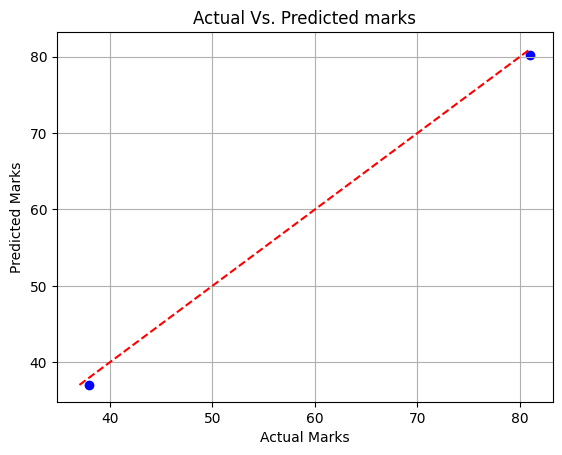

In [11]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, color = "blue")

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color = "red",
    linestyle = "--"
)


plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual Vs. Predicted marks")
plt.grid(True)
plt.show()

K-FOLD

In [13]:
np.random.seed(42)
expanded_indices = np.random.choice(df.index, size=100, replace=True)

x = df.loc[expanded_indices, ["Study_Hours"]].values

x = x + np.random.normal(0, 0.05, x.shape)

y = df.loc[expanded_indices, "Marks"].values
y = y + np.random.normal(0, 0.4, y.shape)


In [15]:
from sklearn.model_selection import KFold

k_values = [4, 5, 6]
test_sizes = [0.20, 0.25, 0.30]
results = []

for k in k_values:
    for test_size in test_sizes:

        x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_size, random_state=42)
    
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        fold_scores = []
        
        for train_idx, val_idx in kf.split(x_train):
            x_fold_train, x_fold_val = x_train[train_idx], x_train[val_idx]
            y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
            
            
            fold_model = LinearRegression()
            fold_model.fit(x_fold_train, y_fold_train)
            
        
            y_fold_pred = fold_model.predict(x_fold_val)
            r2 = r2_score(y_fold_val, y_fold_pred)
            fold_scores.append(r2)
        
        results.append({
            "K (Folds)": k,
            "Test Size (%)": int(test_size * 100),
            "Fold Scores (R²)": [round(score, 4) for score in fold_scores],
            "Average R²": round(np.mean(fold_scores), 4)
        })


In [16]:
df_results = pd.DataFrame(results)
print("===== 9 PARAMETER COMBINATIONS EVALUATION MATRIX =====")
df_results


===== 9 PARAMETER COMBINATIONS EVALUATION MATRIX =====


,K (Folds),Test Size (%),Fold Scores (R²),Average R²
0,4,20,"[0.995, 0.9958, 0.9951, 0.9952]",0.9953
1,4,25,"[0.9964, 0.9953, 0.994, 0.9953]",0.9953
2,4,30,"[0.9969, 0.9939, 0.9935, 0.9931]",0.9944
3,5,20,"[0.9951, 0.9956, 0.9955, 0.9967, 0.995]",0.9956
4,5,25,"[0.996, 0.995, 0.995, 0.9953, 0.9953]",0.9953
5,5,30,"[0.9968, 0.9955, 0.9954, 0.9922, 0.9955]",0.9951
6,6,20,"[0.9961, 0.9922, 0.9958, 0.9959, 0.9968, 0.9937]",0.9951
7,6,25,"[0.9962, 0.9961, 0.993, 0.9948, 0.994, 0.9946]",0.9948
8,6,30,"[0.9976, 0.9948, 0.9939, 0.9866, 0.9922, 0.9968]",0.9936


In [17]:
import matplotlib.pyplot as plt

final_model = LinearRegression()
final_model.fit(x_train, y_train)
y_pred = final_model.predict(x_test)

print("MAE       : ", mean_absolute_error(y_test, y_pred))
print("MSE       : ", mean_squared_error(y_test, y_pred))
print("RMSE      : ", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-squared : ", r2_score(y_test, y_pred))

MAE       :  0.9396940595075076
MSE       :  1.3862110209641003
RMSE      :  1.177374630677976
R-squared :  0.9954027538825454


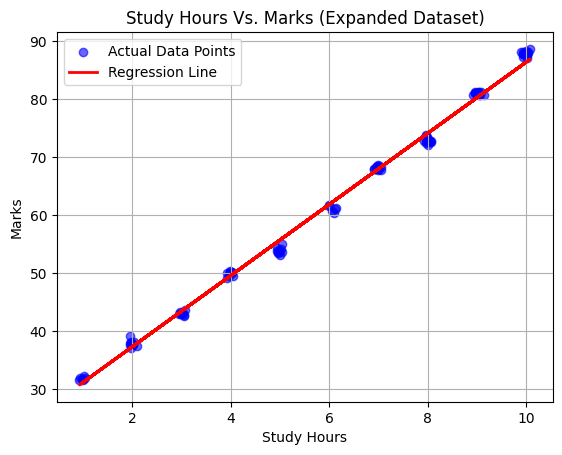

In [18]:
y_plot_line = final_model.predict(x)
plt.scatter(x, y, color="blue", alpha=0.6, label="Actual Data Points")
plt.plot(x, y_plot_line, color="red", linewidth=2, label="Regression Line")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Study Hours Vs. Marks (Expanded Dataset)")
plt.grid(True)
plt.legend()
plt.show()

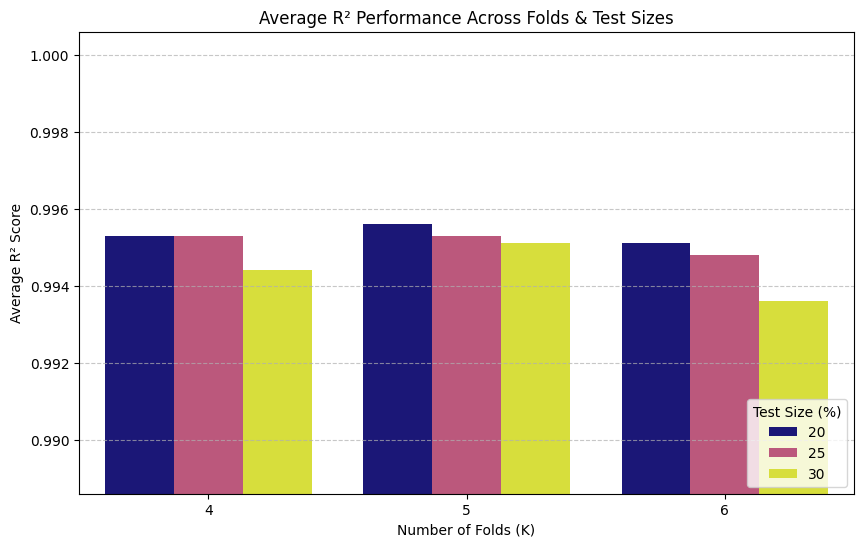

In [19]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=df_results, x="K (Folds)", y="Average R²", hue="Test Size (%)", palette="plasma")

plt.title("Average R² Performance Across Folds & Test Sizes")
plt.xlabel("Number of Folds (K)")
plt.ylabel("Average R² Score")
plt.grid(axis='y', linestyle='--', alpha=0.7)

min_score = df_results["Average R²"].min()
max_score = df_results["Average R²"].max()
plt.ylim(min_score - 0.005, max_score + 0.005)

plt.legend(title="Test Size (%)", loc="lower right")
plt.show()
